In [1]:
import copy
import matplotlib.pyplot as plt
import numpy
import pandas
import plotly
import six
import tensorflow as tf

import CS230

In [2]:
file_paths = CS230.data.get_all_file_paths()

# experiment #1
- input: steering/brake/throttle
- output: discrete derivative of all vehicle movement

### load data sets

In [3]:
file_path = file_paths[0]

data_columns = copy.deepcopy(CS230.data.COLUMNS_HUMAN_INPUT)
data_columns.extend(['vxCG', 'pitchAngle'])
label_columns = CS230.data.COLUMNS_DERIV

train_percent = 0.9
dev_percent = 0.05
test_percent = 0.05

df = CS230.data.load(file_path)
df = CS230.data.stride_rows(df, stride=1000)
df = CS230.data.add_derivatives(df, stride=1)
df = CS230.data.clean_discontinuities(df, stride=1)

df_train, df_dev, df_test = CS230.data.get_data_sets(df, train_percent, dev_percent, test_percent, 
                                                     data_columns, label_columns)

In [4]:
df.head()

,time,handwheelAngle,throttle,brake,clutch,engineSpeed,PPS,gpsTime,latitude,longitude,...,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
0,0.0,29.3,0.7,2.3,13.2,204,5.0,61377.09,NaN,NaN,...,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00
1,1.0,29.4,0.7,0.0,20.6,204,5.0,61378.09,NaN,NaN,...,0.0,0.72,0.0,0.0,-0.10,-0.1,0.3,-0.09,0.0,-0.30
2,2.0,29.4,0.7,0.0,18.6,204,5.0,61379.09,NaN,NaN,...,0.0,-0.26,0.0,0.0,0.20,-0.2,-0.1,0.27,0.0,0.10
3,3.0,29.4,0.7,0.0,21.1,204,5.0,61380.09,NaN,NaN,...,0.0,-0.08,0.0,-0.0,-0.10,0.2,0.1,-0.19,0.0,-0.22
4,4.0,29.4,0.7,0.0,23.5,204,5.0,61381.09,NaN,NaN,...,0.0,0.16,0.0,0.0,0.29,0.0,0.0,0.06,0.0,-0.04


In [5]:
df[data_columns].head()

,brake,throttle,handwheelAngle,vxCG
0,2.3,0.7,29.3,-0.0
1,0.0,0.7,29.4,-0.0
2,0.0,0.7,29.4,-0.0
3,0.0,0.7,29.4,0.0
4,0.0,0.7,29.4,0.0


In [6]:
df[label_columns].head()

,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00
1,0.17,-0.21,0.0,-0.16,0.0,0.72,0.0,0.0,-0.10,-0.1,0.3,-0.09,0.0,-0.30
2,0.00,0.00,0.0,-0.01,0.0,-0.26,0.0,0.0,0.20,-0.2,-0.1,0.27,0.0,0.10
3,0.01,0.00,0.0,0.01,0.0,-0.08,0.0,-0.0,-0.10,0.2,0.1,-0.19,0.0,-0.22
4,-0.02,-0.01,0.0,-0.27,0.0,0.16,0.0,0.0,0.29,0.0,0.0,0.06,0.0,-0.04


In [7]:
df_train.head()

,brake,throttle,handwheelAngle,vxCG,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
2331,0.0,0.9,-6.0,0.02,-0.04,-0.03,0.10,-0.28,-0.06,-0.30,0.01,0.01,-0.29,0.00,0.19,-0.25,0.00,0.13
2232,0.0,1.3,48.7,3.31,0.21,-0.06,0.11,0.51,0.45,-2.27,-0.19,0.05,0.88,-0.29,0.39,0.01,6.41,3.23
66,0.0,2.2,60.8,-0.03,3.05,-0.60,0.00,0.26,0.00,2.38,0.03,-0.04,3.44,0.19,1.28,0.67,0.00,-6.66
1363,3.7,2.9,-1.8,35.85,-0.47,1.82,0.37,-3.80,-0.35,1.87,-4.08,0.09,-6.97,-19.13,-16.68,9.74,1.34,2.26
611,0.0,0.8,-33.1,-0.01,-0.01,-0.11,0.00,0.06,0.00,-0.09,0.00,0.01,-0.09,0.10,-0.10,-0.13,-0.02,1.04


### define model

In [8]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Dense(len(data_columns), activation='relu'))

#model.add(tf.keras.layers.Dropout(0.2))
#model.add(tf.keras.layers.Dense(len(label_columns), activation='relu'))

#model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(len(label_columns), activation='relu'))

#model.add(tf.keras.layers.Dropout(0.2))
#model.add(tf.keras.layers.Dense(len(label_columns), activation='relu'))

#model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(len(label_columns), activation='sigmoid'))

In [9]:
#optimizer = tf.train.AdamOptimizer(0.001)
optimizer = tf.keras.optimizers.SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer, 
    loss='mean_squared_error', 
    metrics=['mean_absolute_error']  # mean absolute error
)

Instructions for updating:
Colocations handled automatically by placer.


### view training data set

In [10]:
df_train.head()

,brake,throttle,handwheelAngle,vxCG,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
2331,0.0,0.9,-6.0,0.02,-0.04,-0.03,0.10,-0.28,-0.06,-0.30,0.01,0.01,-0.29,0.00,0.19,-0.25,0.00,0.13
2232,0.0,1.3,48.7,3.31,0.21,-0.06,0.11,0.51,0.45,-2.27,-0.19,0.05,0.88,-0.29,0.39,0.01,6.41,3.23
66,0.0,2.2,60.8,-0.03,3.05,-0.60,0.00,0.26,0.00,2.38,0.03,-0.04,3.44,0.19,1.28,0.67,0.00,-6.66
1363,3.7,2.9,-1.8,35.85,-0.47,1.82,0.37,-3.80,-0.35,1.87,-4.08,0.09,-6.97,-19.13,-16.68,9.74,1.34,2.26
611,0.0,0.8,-33.1,-0.01,-0.01,-0.11,0.00,0.06,0.00,-0.09,0.00,0.01,-0.09,0.10,-0.10,-0.13,-0.02,1.04


In [11]:
df_train[data_columns].head()

,brake,throttle,handwheelAngle,vxCG
2331,0.0,0.9,-6.0,0.02
2232,0.0,1.3,48.7,3.31
66,0.0,2.2,60.8,-0.03
1363,3.7,2.9,-1.8,35.85
611,0.0,0.8,-33.1,-0.01


In [12]:
df_train[label_columns].head()

,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
2331,-0.04,-0.03,0.10,-0.28,-0.06,-0.30,0.01,0.01,-0.29,0.00,0.19,-0.25,0.00,0.13
2232,0.21,-0.06,0.11,0.51,0.45,-2.27,-0.19,0.05,0.88,-0.29,0.39,0.01,6.41,3.23
66,3.05,-0.60,0.00,0.26,0.00,2.38,0.03,-0.04,3.44,0.19,1.28,0.67,0.00,-6.66
1363,-0.47,1.82,0.37,-3.80,-0.35,1.87,-4.08,0.09,-6.97,-19.13,-16.68,9.74,1.34,2.26
611,-0.01,-0.11,0.00,0.06,0.00,-0.09,0.00,0.01,-0.09,0.10,-0.10,-0.13,-0.02,1.04


### split input data from output labels

In [13]:
x_train = tf.cast(df_train[data_columns].values, tf.float32)
y_train = tf.cast(df_train[label_columns], tf.float32)

### train model

In [14]:
history = model.fit(x_train, y_train, epochs=50, steps_per_epoch=1000)

Instructions for updating:
Use tf.cast instead.
Instructions for updating:
Use tf.cast instead.
Epoch 1/50
1000/1000 [==============================] - 1s 780us/step - loss: 33.8145 - mean_absolute_error: 2.7357
Epoch 2/50
1000/1000 [==============================] - 1s 752us/step - loss: 33.7101 - mean_absolute_error: 2.7050
Epoch 3/50
1000/1000 [==============================] - 1s 744us/step - loss: 33.6905 - mean_absolute_error: 2.7017
Epoch 4/50
1000/1000 [==============================] - 1s 747us/step - loss: 33.6785 - mean_absolute_error: 2.6998
Epoch 5/50
1000/1000 [==============================] - 1s 733us/step - loss: 33.6738 - mean_absolute_error: 2.6986
Epoch 6/50
1000/1000 [==============================] - 1s 737us/step - loss: 33.6711 - mean_absolute_error: 2.6980
Epoch 7/50
1000/1000 [==============================] - 1s 743us/step - loss: 33.6691 - mean_absolute_error: 2.6976
Epoch 8/50
1000/1000 [==============================] - 1s 735us/step - loss: 33.6676 - mean

Text(0.5, 0, 'epoch')

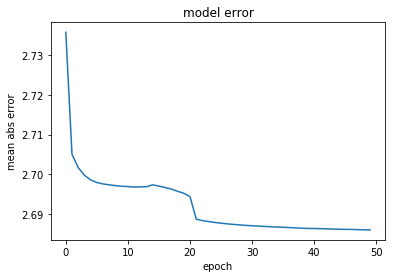

In [15]:
plt.plot(history.history['mean_absolute_error'])
#plt.plot(history.history['val_acc'])
plt.title('model error')
plt.ylabel('mean abs error')
plt.xlabel('epoch')

### view dev set

In [16]:
df_dev.head()

,brake,throttle,handwheelAngle,vxCG,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
1714,0.0,6.6,0.4,49.95,-2.58,4.33,0.42,-3.03,-0.08,-6.62,-6.01,0.01,6.18,-4.91,2.74,29.36,0.44,-1.11
154,0.0,2.2,-3.3,5.36,0.51,-0.92,0.19,0.96,-0.37,0.36,0.00,0.03,5.00,-7.36,-2.55,5.41,0.00,0.85
693,0.0,0.8,-33.1,0.00,0.02,-0.05,0.00,0.27,-0.03,-0.43,0.01,-0.01,0.00,-0.20,0.20,0.02,0.01,-0.32
1338,0.0,56.6,-23.2,33.35,-4.21,3.92,0.67,5.10,-0.70,-5.86,2.39,-0.62,-16.39,-12.07,-23.25,-2.15,-14.30,7.21
2006,0.0,41.7,42.0,24.18,-0.69,-6.39,0.22,-1.03,0.02,-3.55,5.18,0.51,-2.35,7.75,5.29,-0.28,14.21,-16.75


In [17]:
x_dev = tf.cast(df_dev[CS230.data.COLUMNS_HUMAN_INPUT].values, tf.float32)
y_dev = tf.cast(df_dev[CS230.data.COLUMNS_DERIV].values, tf.float32)

### predict against dev set

In [18]:
dev_predictions = model.predict(x_dev, steps=1)

In [19]:
df_dev_predictions = pandas.DataFrame(dev_predictions, columns=CS230.data.COLUMNS_DERIV)
df_dev_predictions.head()

,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
0,7.152557e-07,0.000009,1.490116e-07,0.000000e+00,0.0,7.748604e-07,0.029784,0.000004,2.980232e-07,2.980232e-07,0.000000e+00,0.0,0.0,0.000045
1,9.508641e-01,0.000000,0.000000e+00,1.192093e-07,0.0,1.000000e+00,0.016378,0.000000,0.000000e+00,0.000000e+00,8.940697e-08,0.0,1.0,0.000000
2,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,1.000000e+00,0.324297,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.0,0.000000
3,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000
4,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.019568,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000


In [20]:
df_dev.head()

,brake,throttle,handwheelAngle,vxCG,deriv_axCG,deriv_ayCG,deriv_pitchAngle,deriv_pitchRate,deriv_rollAngle,deriv_rollRate,deriv_vxCG,deriv_vyCG,deriv_wheelAccelFL,deriv_wheelAccelFR,deriv_wheelAccelRL,deriv_wheelAccelRR,deriv_yawAngle,deriv_yawRate
1714,0.0,6.6,0.4,49.95,-2.58,4.33,0.42,-3.03,-0.08,-6.62,-6.01,0.01,6.18,-4.91,2.74,29.36,0.44,-1.11
154,0.0,2.2,-3.3,5.36,0.51,-0.92,0.19,0.96,-0.37,0.36,0.00,0.03,5.00,-7.36,-2.55,5.41,0.00,0.85
693,0.0,0.8,-33.1,0.00,0.02,-0.05,0.00,0.27,-0.03,-0.43,0.01,-0.01,0.00,-0.20,0.20,0.02,0.01,-0.32
1338,0.0,56.6,-23.2,33.35,-4.21,3.92,0.67,5.10,-0.70,-5.86,2.39,-0.62,-16.39,-12.07,-23.25,-2.15,-14.30,7.21
2006,0.0,41.7,42.0,24.18,-0.69,-6.39,0.22,-1.03,0.02,-3.55,5.18,0.51,-2.35,7.75,5.29,-0.28,14.21,-16.75
